In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pickle
import random, warnings, os
import datetime
import time 


warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rulăm pe: {device}")

CSV_PATH = "PEMS-BAY.csv"

# Construirea secvențelor de intrare folosind o fereastră temporală
def build_dataset(data, lookback=12):
    X, y = [], []
    for i in range(len(data)-lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

print("Încarc date...")
df = pd.read_csv(CSV_PATH).dropna()
data = df.iloc[:,1:].values.astype(np.float32)

Rulăm pe: cuda
Încarc date...


In [ ]:
LOOKBACK = 12
X, y = build_dataset(data, LOOKBACK)

# Împărțirea datelor în seturi de antrenare, validare și testare
n_samples = len(X)
train_end = int(0.7*n_samples)
val_end   = int(0.85*n_samples)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

# Normalizarea datelor în intervalul [0,1]
scaler_X = MinMaxScaler()
X_train_s = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_val_s = scaler_X.transform(X_val.reshape(-1, X_val.shape[2])).reshape(X_val.shape)
X_test_s = scaler_X.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

scaler_y = MinMaxScaler()
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# Conversia datelor în tensori PyTorch
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_s, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)

In [2]:
class LSTM(nn.Module):
    def __init__(self, input_dim=325, hidden_dim=128, output_dim=325, num_layers=2):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # x: (batch, lookback, 325)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :]) 
        return self.fc(out)

In [5]:
print("\n Antrenare LSTM...")
model_lstm = LSTM(input_dim=325, hidden_dim=128, output_dim=325).to(device)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
criterion = nn.MSELoss()

start_lstm = time.time()
for epoch in range(50):
    model_lstm.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        pred = model_lstm(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:  # Evaluarea pe setul de validare la fiecare 10 epoci
        model_lstm.eval()
        with torch.no_grad():
            val_mse = sum(criterion(model_lstm(xv.to(device)), yv.to(device)).item() for xv, yv in val_loader) / len(val_loader)
        print(f"Epoch {epoch+1:2d}/50 | Loss: {epoch_loss/len(train_loader):.6f} | Val MSE: {val_mse:.6f}")

print(f" LSTM antrenat în {(time.time()-start_lstm)/60:.2f} minute.")


 Antrenare Baseline LSTM...
Epoch 10/50 | Loss: 0.003733 | Val MSE: 0.004483
Epoch 20/50 | Loss: 0.002992 | Val MSE: 0.003737
Epoch 30/50 | Loss: 0.002721 | Val MSE: 0.003412
Epoch 40/50 | Loss: 0.002566 | Val MSE: 0.003283
Epoch 50/50 | Loss: 0.002458 | Val MSE: 0.003189
 LSTM antrenat în 6.21 minute.


In [8]:
# Evaluarea modelului pe setul de testare
model_lstm.eval()
with torch.no_grad():
    X_test_device = X_test_t.to(device)
    pred_test = model_lstm(X_test_device).cpu().numpy()

# Revenirea la valorile originale (mph)
y_pred_inv = scaler_y.inverse_transform(pred_test)
y_real_inv = scaler_y.inverse_transform(y_test_s)

# Calculul metricilor de evaluare
mse = mean_squared_error(y_real_inv, y_pred_inv)
mae = mean_absolute_error(y_real_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_real_inv, y_pred_inv)
var_ratio = np.var(y_pred_inv) / np.var(y_real_inv)

print("\n REZULTATE LSTM")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f} mph")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print(f"Var  : {var_ratio:.4f} (Raport Varianță)")


# 6. Salvare rezultate

results_lstm = {
    "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "model": "LSTM", 
    "version": "v1",
    "lookback": LOOKBACK,
    "gcn_channels": 0,            
    "hidden_units": 128,             
    "learning_rate": "0.001",    
    "dropout": "0.2",
    "batch_size": 32,
    "epochs": 50,
    "MSE": f"{mse:.6f}",
    "RMSE": f"{rmse:.4f}",
    "MAE": f"{mae:.4f}",
    "R2": f"{r2:.4f}",
    "Var_Ratio": f"{var_ratio:.4f}"
}


if not os.path.exists("Rezultate"):
    os.makedirs("Rezultate")

results_path = "Rezultate/log_experimente.csv"
pd.DataFrame([results_lstm]).to_csv(results_path, mode='a', header=not os.path.exists(results_path), index=False)
np.save("Rezultate/preds_LSTM_Baseline.npy", y_pred_inv)

print(f" Rezultatele LSTM au fost adăugate în {results_path}!")


 REZULTATE LSTM
MSE  : 15.6185
MAE  : 2.1898 mph
RMSE : 3.9520
R2   : 0.7040
Var  : 0.7733 (Raport Varianță)
 Rezultatele LSTM au fost adăugate în Rezultate/log_experimente.csv!


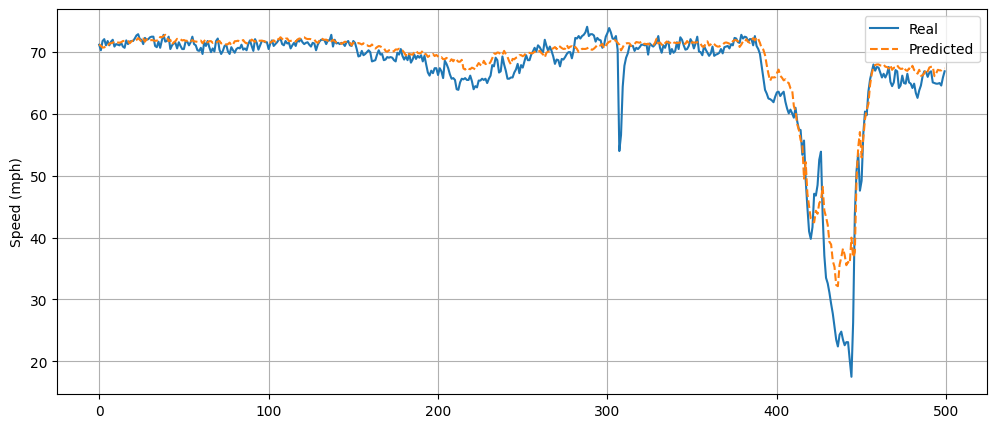

In [10]:
# Reprezentarea grafică a predicțiilor
plt.figure(figsize=(12,5))
plt.plot(y_real_inv[:500, 0], label="Real")
plt.plot(y_pred_inv[:500, 0], '--', label="Predicted")
plt.ylabel("Speed (mph)")
plt.legend()
plt.grid()
plt.show()
